In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
df.shape

(42000, 785)

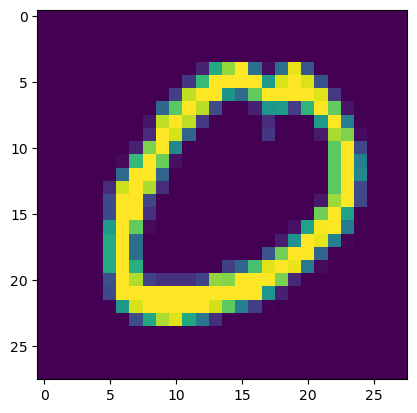

In [3]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))

In [4]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train.shape

(33600, 784)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

9.072864055633545


In [8]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9651190476190477

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=200)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [11]:
X_train_trf.shape


(33600, 200)

In [12]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
y_pred_trf = knn.predict(X_test_trf)


In [14]:
accuracy_score(y_test,y_pred)

0.9651190476190477

In [16]:
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf

array([[-0.84756762,  1.7467536 ],
       [-2.2090181 , -5.3966156 ],
       [-4.19081635,  0.60897468],
       ...,
       [ 4.46291537, -0.63837679],
       [-4.5016082 , -1.19691725],
       [ 0.11943076,  0.96090267]])

In [17]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [18]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf

array([[-0.84756762,  1.7467536 ,  5.42085949],
       [-2.2090181 , -5.3966156 ,  1.87038904],
       [-4.19081635,  0.60897468,  6.87752512],
       ...,
       [ 4.46291537, -0.63837679,  4.81249498],
       [-4.5016082 , -1.19691725, -2.75720106],
       [ 0.11943076,  0.96090267, -1.35292383]])

In [20]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter_3d(x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)

fig.show()

In [21]:
pca.explained_variance_ # Eigen values

array([40.71663636, 29.14088312, 26.81721425])

In [22]:
pca.components_.shape # Eigen vectors

(3, 784)

In [23]:
pca.explained_variance_ratio_


array([0.05799918, 0.04150999, 0.03820002])

In [24]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [25]:
pca.explained_variance_.shape

(784,)

In [26]:
pca.components_.shape

(784, 784)

In [27]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05799918, 0.09950917, 0.1377092 , 0.16736993, 0.19318233,
       0.21565205, 0.23536973, 0.25323744, 0.26894271, 0.28329551,
       0.29697313, 0.30931628, 0.32079432, 0.33198755, 0.34263652,
       0.35281075, 0.36236381, 0.37176447, 0.38094675, 0.38993126,
       0.39843847, 0.40665799, 0.41450114, 0.4221036 , 0.42945695,
       0.43655166, 0.44355656, 0.4503087 , 0.45670593, 0.46297924,
       0.4691729 , 0.47522423, 0.48112097, 0.48692687, 0.49264839,
       0.49820532, 0.50366875, 0.50897338, 0.51409922, 0.51910757,
       0.5240261 , 0.52887714, 0.53359972, 0.53824427, 0.54281422,
       0.5473139 , 0.55179168, 0.55622667, 0.56064334, 0.56494291,
       0.56917533, 0.5733511 , 0.57746176, 0.58148675, 0.58547992,
       0.58946312, 0.59336758, 0.59714261, 0.60087936, 0.60457987,
       0.60820612, 0.61177812, 0.61530108, 0.61878842, 0.62222742,
       0.62561036, 0.62897869, 0.63231763, 0.63555434, 0.63876658,
       0.64193464, 0.64506916, 0.64816639, 0.65124861, 0.65431

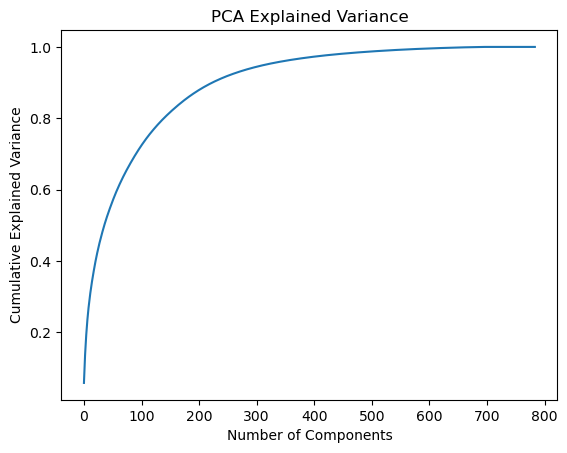

In [29]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()